# Fases 6 y 7 — Entrenamiento, resultados y comparación de arquitecturas

## Cómo se entrenó

| Parámetro | Valor | Por qué |
|---|---|---|
| Pérdida | MSE | Penaliza los errores grandes; coherente con el RMSE que se reporta |
| Optimizador | Adam, lr = 0.001 | Estándar y robusto, sin necesidad de ajuste fino |
| Tamaño de lote | 128 | Buen equilibrio entre velocidad en CPU y estabilidad del gradiente |
| Épocas | máx. 100 | En la práctica nunca se alcanza: Early Stopping corta antes |
| **Early Stopping** | paciencia 5, mejora mínima 5·10⁻⁴ (≈ 0.1 MW), restaura los mejores pesos | Para cuando la validación deja de mejorar de forma relevante |
| ReduceLROnPlateau | factor 0.5, paciencia 3 | Si la validación se estanca, reduce el paso de aprendizaje para afinar |
| Mezcla de lotes | sí, solo dentro de train | Cada ventana ya conserva su orden temporal interno; mezclar ventanas no filtra futuro |

> **Nota sobre el criterio de parada.** Una primera versión usaba paciencia 10 sin mejora mínima. El análisis de sus curvas (`resultados/analisis_paciencia10.csv`) mostró que el **73 % del tiempo** se gastaba en ganar menos de 0.5 MW. Con el criterio actual el entrenamiento es entre 2.5 y 4 veces más rápido, a cambio de 0.2–1.4 MW más de error. Todos los modelos de esta tabla usan el mismo criterio, así que la comparación es justa.

**Experimentos:** 18 corridas de la grilla (3 arquitecturas × 3 ventanas × 2 tratamientos de anomalías) + 10 corridas para las preguntas de análisis (notebook 05). Todas las métricas de test se calculan sobre **el mismo conjunto de 2 110 horas** (ver notebook 03).

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
import experimentos as E
from modelos import NOMBRES
from metricas import metricas
from graficos import aplicar_estilo, AZUL, NARANJA, AQUA, AMARILLO, TINTA_2, REJILLA
aplicar_estilo()
FIG = RAIZ / "resultados/figuras"
COLOR = {"A": AZUL, "B": NARANJA, "C": AQUA}

res = E.cargar_resultados()
grid = res[res.id.str.startswith("grid_")].copy()
grid["modelo"] = grid.arquitectura.map(NOMBRES)
baselines = pd.read_csv(RAIZ / "resultados/baselines.csv", index_col=0)
def hist(id_):
    return json.loads((E.DIR_RES / f"{id_}.json").read_text(encoding="utf-8"))["historial"]
def pred(id_):
    return pd.read_parquet(E.DIR_RES / f"{id_}_pred_test.parquet").query("en_comun").reset_index(drop=True)
def con_huecos(p):
    # Reindexa a rejilla horaria: las horas excluidas se ven como huecos, no como líneas rectas
    rejilla = pd.date_range(p.ts_objetivo.min(), p.ts_objetivo.max(), freq="h")
    return p.set_index("ts_objetivo").reindex(rejilla).rename_axis("ts_objetivo").reset_index()
print(f"Corridas cargadas: {len(res)} (grilla: {len(grid)})")

Corridas cargadas: 28 (grilla: 18)


## 1. Tabla de resultados (test, en MW)

Formato pedido por el taller. *Épocas* = época cuyos pesos se restauraron (el mejor modelo según validación).

In [2]:
tabla = grid.rename(columns={"MAE_test_comun": "MAE", "MSE_test_comun": "MSE", "RMSE_test_comun": "RMSE",
                             "MAPE_test_comun": "MAPE", "R2_test_comun": "R²", "mejor_epoca": "Épocas"})
tabla = tabla[["modelo", "ventana", "tratamiento", "MAE", "MSE", "RMSE", "MAPE", "R²", "Épocas",
               "epocas_entrenadas", "parametros", "segundos"]].sort_values(["tratamiento", "modelo", "ventana"])
b = baselines.rename(columns={"R2": "R²"})[["MAE", "MSE", "RMSE", "MAPE", "R²"]].reset_index(names="modelo")
b["ventana"], b["tratamiento"] = "—", "—"
tabla_final = pd.concat([tabla, b], ignore_index=True)
tabla_final.to_csv(RAIZ / "resultados/tabla_resultados.csv", index=False)
tabla_final.round({"MAE": 2, "MSE": 1, "RMSE": 2, "MAPE": 2, "R²": 4})

,modelo,ventana,tratamiento,MAE,MSE,RMSE,MAPE,R²,Épocas,epocas_entrenadas,parametros,segundos
0,A. LSTM base,12,A,19.79,618.2,24.86,3.37,0.9007,22.0,27.0,20289.0,24.8
1,A. LSTM base,24,A,19.38,592.8,24.35,3.31,0.9047,35.0,40.0,20289.0,52.9
2,A. LSTM base,48,A,19.79,618.1,24.86,3.39,0.9007,18.0,23.0,20289.0,51.7
3,B. LSTM profunda,12,A,19.55,597.8,24.45,3.33,0.9039,33.0,38.0,135585.0,112.0
4,B. LSTM profunda,24,A,19.26,590.1,24.29,3.30,0.9052,15.0,20.0,135585.0,140.9
5,B. LSTM profunda,48,A,19.29,594.5,24.38,3.30,0.9045,26.0,31.0,135585.0,324.7
6,C. Conv1D + LSTM,12,A,20.07,642.4,25.34,3.43,0.8968,16.0,21.0,48193.0,25.8
7,C. Conv1D + LSTM,24,A,19.78,623.5,24.97,3.38,0.8998,20.0,25.0,48193.0,42.0
8,C. Conv1D + LSTM,48,A,20.07,638.1,25.26,3.44,0.8974,14.0,19.0,48193.0,62.2
9,A. LSTM base,12,B,19.91,625.0,25.00,3.41,0.8996,19.0,24.0,20289.0,12.6


**Lectura de la tabla:**
- **Las 18 configuraciones LSTM quedan entre 24.1 y 26.3 MW de RMSE** (R² ≈ 0.89–0.91). Todas superan con amplitud al mejor baseline: el estacional semanal, con 37.2 MW. Es una mejora de **~35 %**.
- **Las diferencias entre configuraciones son pequeñas:** la mayoría está dentro de ±0.5 MW, es decir, ~2 % del error. Con una sola semilla por configuración, diferencias de ese tamaño **pueden deberse a la inicialización aleatoria**. Por eso las conclusiones se basan en tendencias consistentes, no en el primer lugar de la tabla.
- El MAPE ronda el **3.3 %**: en promedio, el modelo se equivoca por ~20 MW sobre demandas de ~600 MW.

## 2. Comparación de modelos

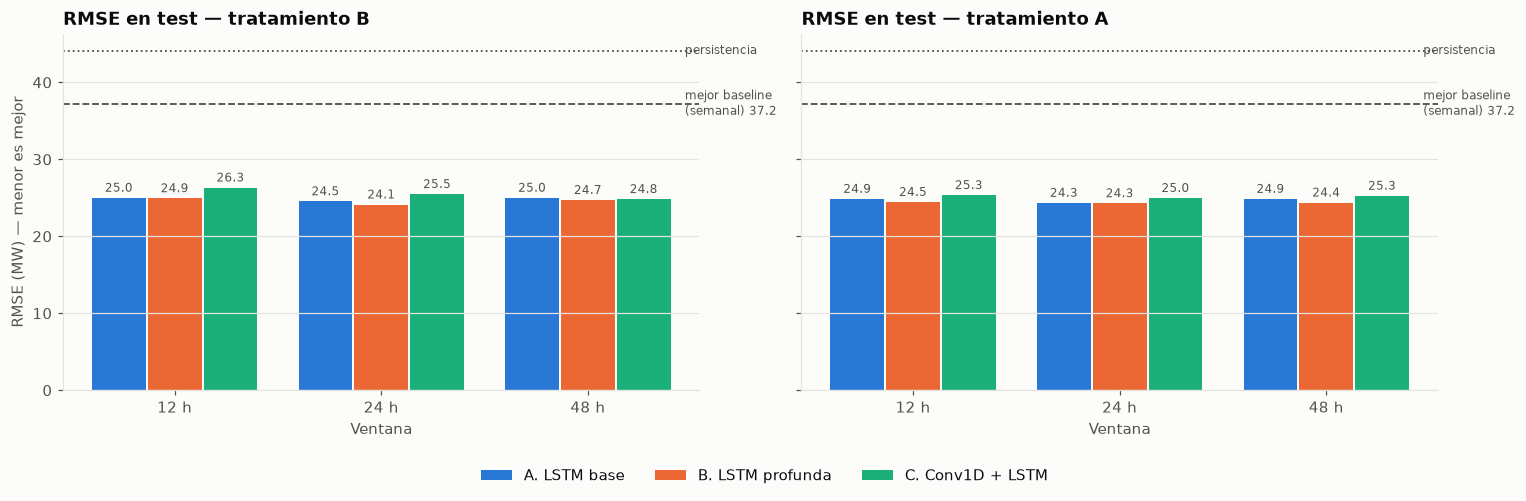

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
for k, trat in enumerate(["B", "A"]):
    g = grid[grid.tratamiento == trat]
    x = np.arange(3); w = 0.26
    for j, arq in enumerate(["A", "B", "C"]):
        v = g[g.arquitectura == arq].sort_values("ventana")
        barras = ax[k].bar(x + (j - 1) * (w + 0.01), v.RMSE_test_comun, w, color=COLOR[arq], label=NOMBRES[arq])
        ax[k].bar_label(barras, fmt="%.1f", fontsize=8, color=TINTA_2, padding=2)
    mejor_base = baselines.RMSE.min()
    ax[k].axhline(mejor_base, color=TINTA_2, linestyle="--", linewidth=1.2)
    ax[k].text(2.45, mejor_base, f" mejor baseline\n (semanal) {mejor_base:.1f}", va="center", fontsize=8, color=TINTA_2)
    ax[k].axhline(baselines.loc["Persistencia", "RMSE"], color=TINTA_2, linestyle=":", linewidth=1.2)
    ax[k].text(2.45, baselines.loc["Persistencia", "RMSE"], " persistencia", va="center", fontsize=8, color=TINTA_2)
    ax[k].set_xticks(x, ["12 h", "24 h", "48 h"]); ax[k].set_xlabel("Ventana")
    ax[k].set_title(f"RMSE en test — tratamiento {trat}")
ax[0].set_ylabel("RMSE (MW) — menor es mejor")
fig.legend(*ax[0].get_legend_handles_labels(), loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.savefig(FIG / "05_comparacion_modelos.png"); plt.show()

**Tendencias:**
1. **LSTM base (A) y LSTM profunda (B) rinden casi igual;** B gana por poco con 24 h. Que la profunda, con **6.7 veces más parámetros** (135 585 vs. 20 289), no mejore claramente indica que **el problema no necesita tanta capacidad**: a una hora vista, la señal es relativamente simple.
2. **La Conv1D + LSTM (C) es la más débil con ventanas cortas y mejora con 48 h.** Es coherente con su diseño: las convoluciones necesitan una secuencia larga para extraer patrones locales útiles. Además, el criterio de parada la perjudica: en el análisis de curvas fue la que más mejoraba tarde.
3. **La ventana de 24 h es la mejor o empata en A y B**, como anticipó el ACF del EDA: con 24 h el modelo ve la misma hora del día anterior (lag 24 = 0.75). Pasar a 48 h no aporta (PACF ≈ 0 después del lag 27) y añade costo.

### 2.1 Tratamiento de anomalías: A (descartar) vs. B (recuperar)

Recordatorio: en **A** se descartan las ventanas que contienen alguna de las 40 horas con demanda en conflicto. En **B** se recupera ese valor desde la otra medición real de la misma hora.

In [4]:
piv = grid.pivot_table(index=["modelo", "ventana"], columns="tratamiento", values="RMSE_test_comun").round(2)
piv["B − A"] = (piv["B"] - piv["A"]).round(2)
piv

tratamiento                   A      B  B − A
modelo           ventana                     
A. LSTM base     12       24.86  25.00   0.14
                 24       24.35  24.54   0.19
                 48       24.86  25.00   0.14
B. LSTM profunda 12       24.45  24.94   0.49
                 24       24.29  24.13  -0.16
                 48       24.38  24.71   0.33
C. Conv1D + LSTM 12       25.34  26.33   0.99
                 24       24.97  25.47   0.50
                 48       25.26  24.83  -0.43

**Conclusión:**
- **El tratamiento A (descartar) es ligeramente mejor en 7 de 9 configuraciones**, por 0.14–0.99 MW. La mayoría de las diferencias es menor a 0.5 MW, del orden del ruido entre semillas, pero el signo es bastante consistente.
- Una explicación posible: en B, el valor recuperado viene de `demanda_objetivo(t−1)`. En 7 de esas 40 horas ambas mediciones se contradecían sin que se pudiera saber cuál era la correcta (casos "dudosos" de la Fase 1). Descartarlas evita entrenar con un valor posiblemente erróneo. Con los datos disponibles no se puede confirmar.
- En la **mejor configuración** (LSTM profunda, 24 h) el orden se invierte: B es 0.16 MW mejor.
- **Conclusión práctica:** con solo 40 horas afectadas de 17 520, el tratamiento **no cambia las conclusiones**, y eso confirma que la limpieza es robusta. Para producción se usa **B**, porque fue la mejor configuración en validación y porque puede predecir aunque una hora de la ventana haya tenido un problema de medición.

## 3. Curvas de pérdida: entrenamiento vs. validación

La línea vertical gris marca la época cuyos pesos se restauraron.

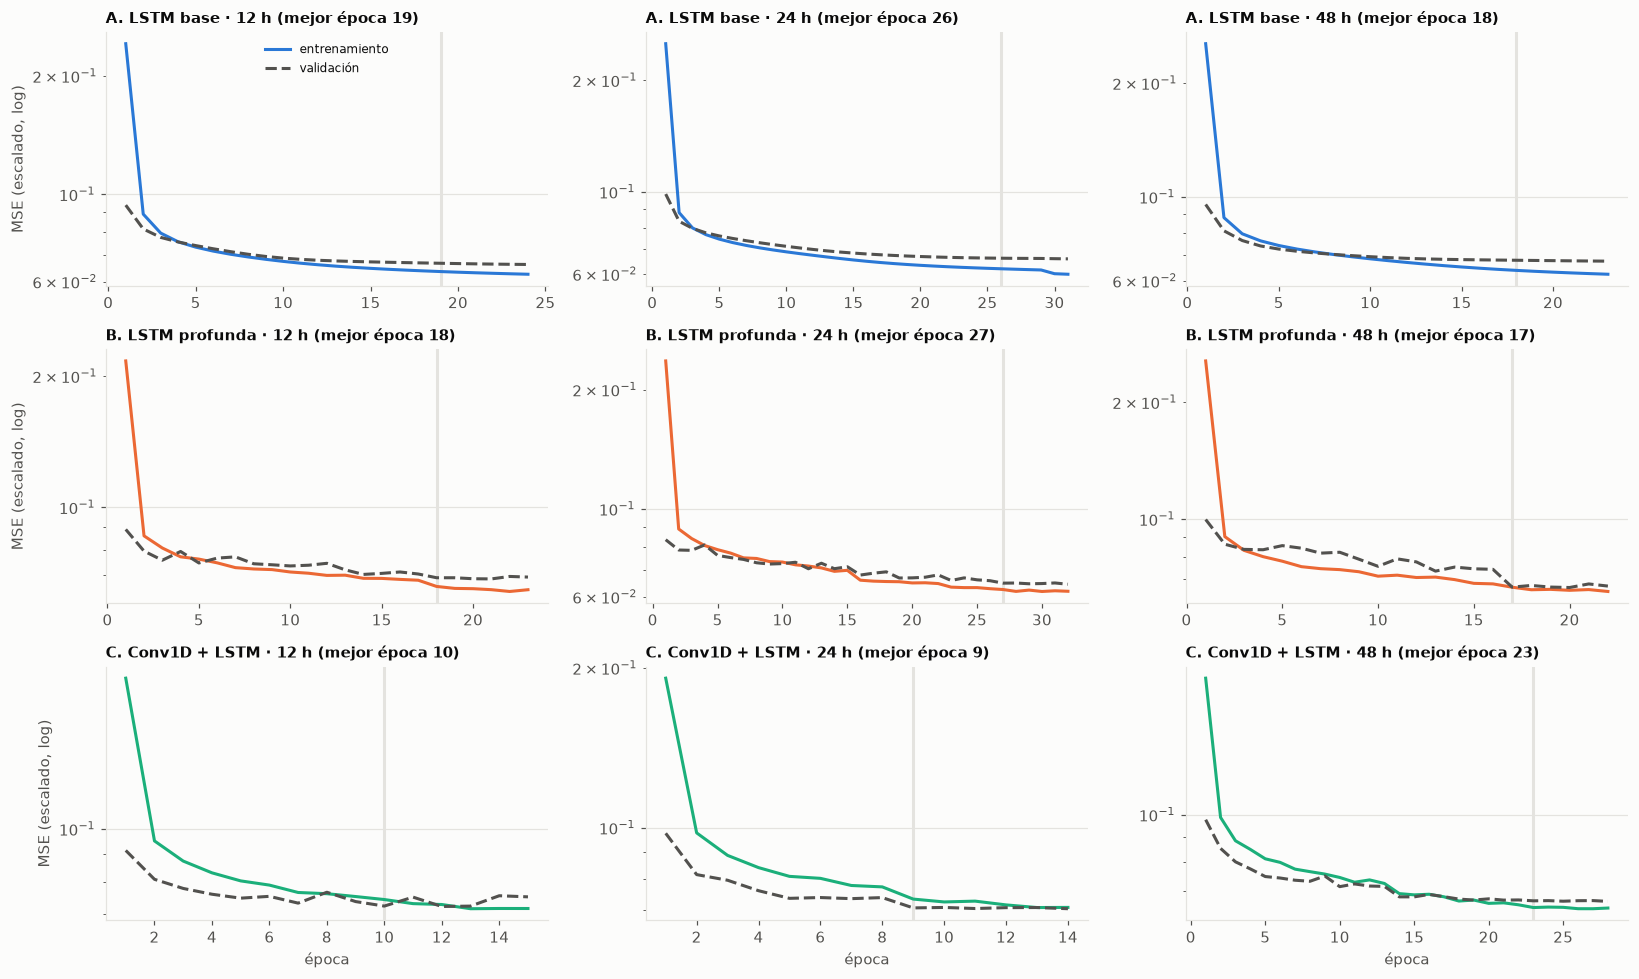

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=False)
for i, arq in enumerate(["A", "B", "C"]):
    for j, n in enumerate([12, 24, 48]):
        a = axes[i, j]; h = hist(f"grid_{arq}_n{n}_B")
        ep = np.arange(1, len(h["loss"]) + 1)
        a.plot(ep, h["loss"], color=COLOR[arq], label="entrenamiento")
        a.plot(ep, h["val_loss"], color=TINTA_2, linestyle="--", label="validación")
        mejor = E.epoca_restaurada(h["val_loss"])
        a.axvline(mejor, color=REJILLA, linewidth=2, zorder=0)
        a.set_title(f"{NOMBRES[arq]} · {n} h (mejor época {mejor})", fontsize=10)
        a.set_yscale("log")
        if j == 0: a.set_ylabel("MSE (escalado, log)")
        if i == 2: a.set_xlabel("época")
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "05_curvas_loss.png"); plt.show()

**Cómo leerlas:**
- Si la curva de **validación** sube mientras la de entrenamiento sigue bajando → **sobreajuste**.
- Aquí ambas bajan juntas y se estabilizan, con la validación ligeramente por encima. Es el patrón de un modelo que **generaliza bien**.
- La pérdida de validación queda por encima de la de entrenamiento en parte porque **la validación es julio–septiembre**, la temporada de picos más altos y más difíciles de predecir.

## 4. Sobreajuste y generalización: train vs. validación vs. test

In [6]:
sa = grid[grid.tratamiento == "B"][["modelo", "ventana", "RMSE_train", "RMSE_val", "RMSE_test_comun"]].copy()
sa["brecha val − train"] = sa.RMSE_val - sa.RMSE_train
sa["brecha %"] = 100 * sa["brecha val − train"] / sa.RMSE_train
sa.sort_values(["modelo", "ventana"]).round(2)

,modelo,ventana,RMSE_train,RMSE_val,RMSE_test_comun,brecha val − train,brecha %
5,A. LSTM base,12,24.51,25.42,25.00,0.91,3.72
7,A. LSTM base,24,24.50,25.30,24.54,0.80,3.28
9,A. LSTM base,48,24.81,25.65,25.00,0.85,3.41
11,B. LSTM profunda,12,24.75,25.83,24.94,1.08,4.36
13,B. LSTM profunda,24,24.04,25.06,24.13,1.03,4.27
15,B. LSTM profunda,48,24.64,25.43,24.71,0.79,3.21
17,C. Conv1D + LSTM,12,25.64,26.46,26.33,0.82,3.19
19,C. Conv1D + LSTM,24,25.42,26.14,25.47,0.72,2.82
21,C. Conv1D + LSTM,48,24.05,25.44,24.83,1.39,5.78


**No hay sobreajuste relevante:** la brecha entre validación y entrenamiento es de ~1 MW (~4 %) en todas las configuraciones.

Además, el error en **test** (oct–dic, datos que el modelo nunca vio y que no se usaron para ninguna decisión) es **igual o menor** que en validación. El modelo **generaliza** a un periodo futuro, con otra estación del año.

Ojo: el R² de test es algo menor que el de validación aunque el RMSE sea parecido. Es el efecto que anticipó el EDA: el test tiene menos variabilidad, así que el mismo error en MW pesa más en el R².

## 5. Demanda real vs. predicha (mejor modelo)

Mejor configuración en test: grid_B_n24_B | RMSE 24.13


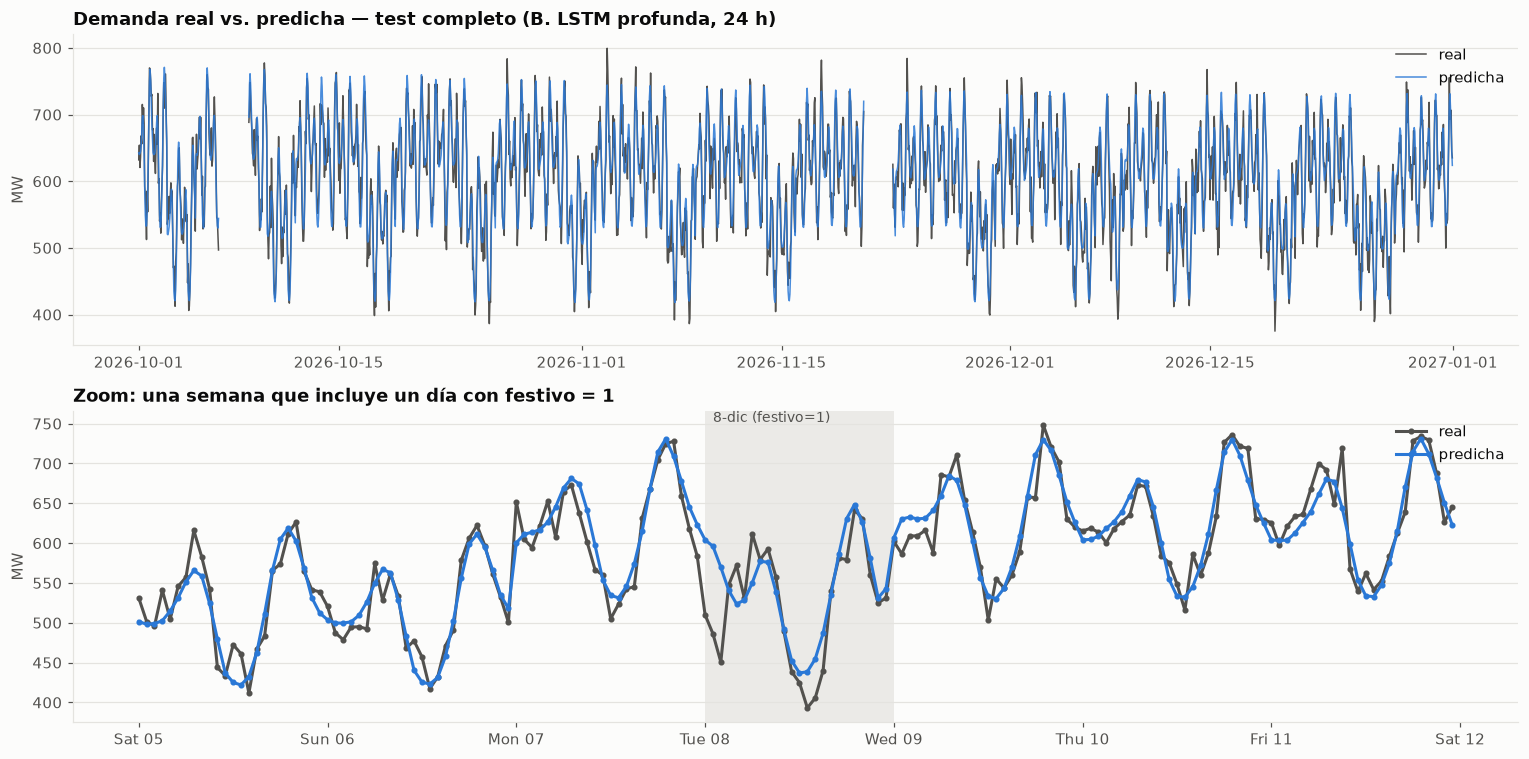

In [7]:
mejor = grid.sort_values("RMSE_test_comun").iloc[0]
print("Mejor configuración en test:", mejor.id, "| RMSE", round(mejor.RMSE_test_comun, 2))
p = pred(mejor.id)
fig, ax = plt.subplots(2, 1, figsize=(14, 7))
ph = con_huecos(p)
ax[0].plot(ph.ts_objetivo, ph.real, color=TINTA_2, linewidth=1, label="real")
ax[0].plot(ph.ts_objetivo, ph.pred, color=AZUL, linewidth=1, alpha=0.85, label="predicha")
ax[0].set_title(f"Demanda real vs. predicha — test completo ({NOMBRES[mejor.arquitectura]}, {mejor.ventana} h)")
ax[0].set_ylabel("MW"); ax[0].legend(loc="upper right")
z = p[(p.ts_objetivo >= "2026-12-05") & (p.ts_objetivo < "2026-12-12")]
ax[1].plot(z.ts_objetivo, z.real, color=TINTA_2, marker="o", markersize=3, label="real")
ax[1].plot(z.ts_objetivo, z.pred, color=AZUL, marker="o", markersize=3, label="predicha")
ax[1].axvspan(pd.Timestamp("2026-12-08"), pd.Timestamp("2026-12-09"), color=REJILLA, alpha=0.7, linewidth=0)
ax[1].text(pd.Timestamp("2026-12-08 01:00"), ax[1].get_ylim()[1], "8-dic (festivo=1)", va="top", fontsize=9, color=TINTA_2)
ax[1].set_title("Zoom: una semana que incluye un día con festivo = 1"); ax[1].set_ylabel("MW"); ax[1].legend(loc="upper right")
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
plt.tight_layout(); plt.savefig(FIG / "05_real_vs_predicha.png"); plt.show()

El modelo sigue de cerca el ciclo diario, los fines de semana y la tendencia estacional del test.

En el zoom, el día marcado con `festivo = 1` (8-dic) muestra la principal debilidad del modelo:
- Entre las 00:00 y las 02:00 de ese martes, la demanda real cae a 450–510 MW. El modelo predice 570–604 MW, el nivel de una madrugada laboral normal.
- **El error de las 02:00 (+119 MW) es el mayor de todo el test** (ver la siguiente gráfica).
- Desde las 03:00 el modelo se corrige, gracias a la demanda reciente que ve en la ventana.
- **Causa:** solo hubo 8 días con `festivo = 1` en entrenamiento, demasiado pocos para que el modelo aprenda bien su efecto.

## 6. Error de predicción

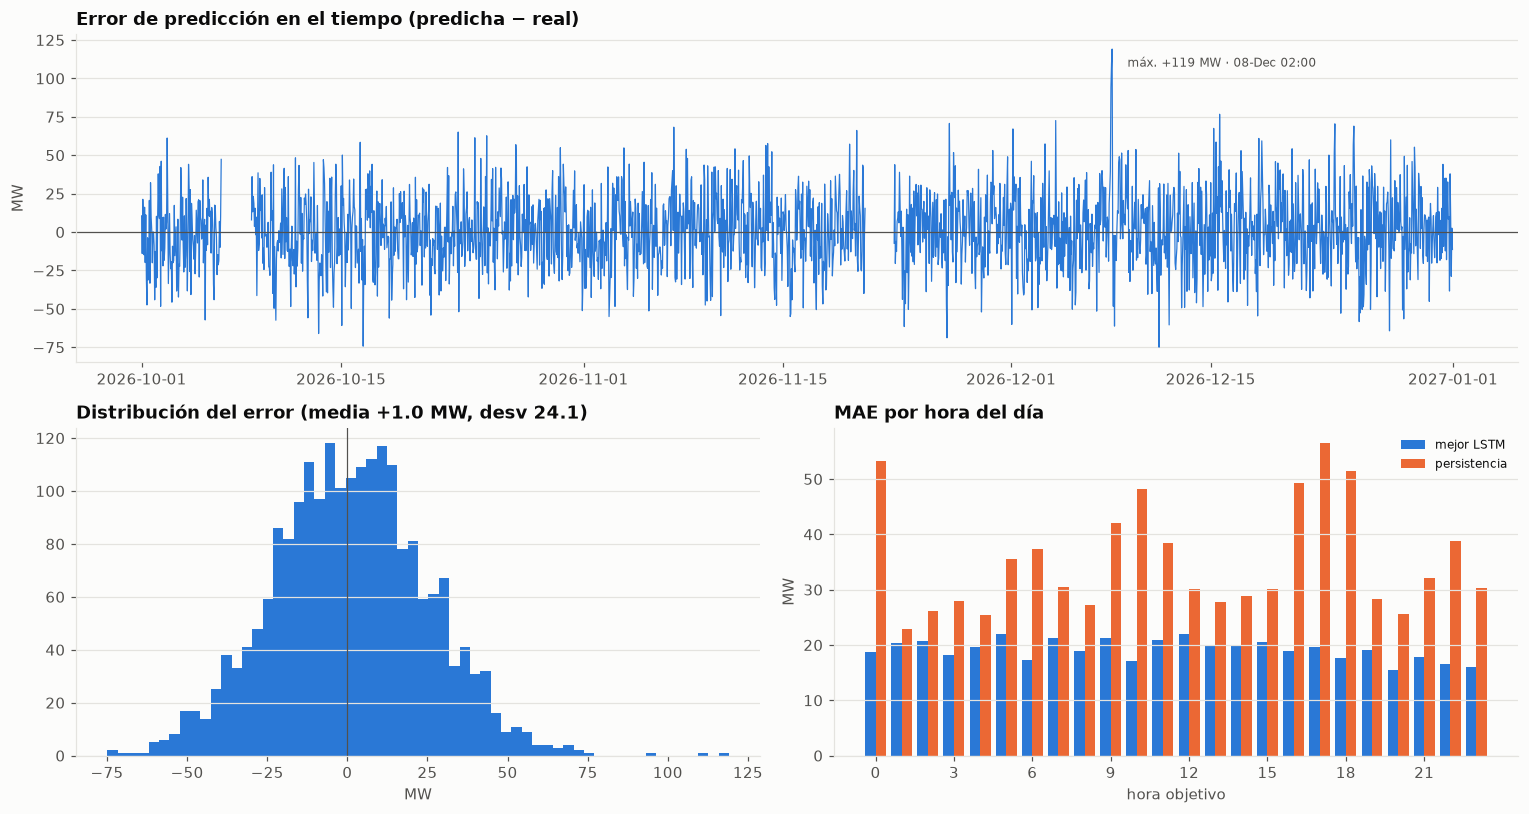

In [8]:
p["error"] = p.pred - p.real
fig = plt.figure(figsize=(14, 7.5))
a1 = plt.subplot2grid((2, 2), (0, 0), colspan=2); a2 = plt.subplot2grid((2, 2), (1, 0)); a3 = plt.subplot2grid((2, 2), (1, 1))
ph = con_huecos(p)
a1.plot(ph.ts_objetivo, ph.pred - ph.real, color=AZUL, linewidth=0.8)
i_max = p.error.abs().idxmax()
a1.annotate(f"máx. {p.error[i_max]:+.0f} MW · {p.ts_objetivo[i_max]:%d-%b %H:%M}",(p.ts_objetivo[i_max], p.error[i_max]),
             xytext=(10, -5), textcoords="offset points", fontsize=8, color=TINTA_2, va="top"); a1.axhline(0, color=TINTA_2, linewidth=0.8)
a1.set_title("Error de predicción en el tiempo (predicha − real)"); a1.set_ylabel("MW")
a2.hist(p.error, bins=60, color=AZUL); a2.axvline(0, color=TINTA_2, linewidth=0.8)
a2.set_title(f"Distribución del error (media {p.error.mean():+.1f} MW, desv {p.error.std():.1f})"); a2.set_xlabel("MW")
por_hora = p.assign(h=p.ts_objetivo.dt.hour, abs=p.error.abs()).groupby("h")["abs"].mean()
base = pd.read_parquet(RAIZ / "data/processed/dataset_limpio.parquet").set_index("timestamp")["demanda_mw_recuperada"]
pers_err = (base.reindex(p.ts_objetivo - pd.Timedelta(hours=1)).to_numpy() - p.real.to_numpy())
pers_hora = pd.Series(np.abs(pers_err), index=p.ts_objetivo.dt.hour.to_numpy()).groupby(level=0).mean()
w = 0.4
a3.bar(por_hora.index - w/2, por_hora.values, w, color=AZUL, label="mejor LSTM")
a3.bar(pers_hora.index + w/2, pers_hora.values, w, color=NARANJA, label="persistencia")
a3.set_title("MAE por hora del día"); a3.set_xlabel("hora objetivo"); a3.set_ylabel("MW"); a3.legend(fontsize=8)
a3.set_xticks(range(0, 24, 3))
plt.tight_layout(); plt.savefig(FIG / "05_error_prediccion.png"); plt.show()

**Lectura:**
- **Los errores se centran en ~0 y son simétricos.** No hay un sesgo sistemático global.
- **Por hora:** la mejor LSTM reduce el error en **todas** las horas frente a la persistencia, y sobre todo en las **rampas** (subida de la tarde y bajada de la mañana). Ahí la persistencia siempre "llega una hora tarde". Es justo donde la ventana y el calendario le dan ventaja a la LSTM.

## 7. Desempeño en picos de demanda

`MAE_picos` = error medio en el 5 % de horas con mayor demanda del test. `sesgo_picos` < 0 indica que el modelo **subestima** los picos.

In [9]:
picos = grid[grid.tratamiento == "B"][["modelo", "ventana", "RMSE_test_comun", "MAE_picos_test_comun", "sesgo_picos_test_comun"]]
b = baselines[["RMSE", "MAE_picos", "sesgo_picos"]].rename(columns={"RMSE": "RMSE_test_comun",
        "MAE_picos": "MAE_picos_test_comun", "sesgo_picos": "sesgo_picos_test_comun"}).reset_index(names="modelo")
pd.concat([picos.sort_values(["modelo", "ventana"]), b]).round(2)

,modelo,ventana,RMSE_test_comun,MAE_picos_test_comun,sesgo_picos_test_comun
5,A. LSTM base,12.0,25.00,20.57,-13.23
7,A. LSTM base,24.0,24.54,19.29,-12.91
9,A. LSTM base,48.0,25.00,20.69,-16.56
11,B. LSTM profunda,12.0,24.94,20.49,-15.01
13,B. LSTM profunda,24.0,24.13,19.20,-13.49
15,B. LSTM profunda,48.0,24.71,20.31,-14.80
17,C. Conv1D + LSTM,12.0,26.33,20.68,-14.48
19,C. Conv1D + LSTM,24.0,25.47,22.73,-19.23
21,C. Conv1D + LSTM,48.0,24.83,22.21,-19.36
0,Persistencia,NaN,44.08,40.01,-32.54


**Lectura:**
- **Todas las LSTM subestiman los picos** (sesgo de −13 a −19 MW). Es típico de los modelos entrenados con MSE: tienden a ser "conservadores" y predecir hacia la media.
- Frente a la **persistencia** (−33 MW de sesgo, 40 MW de error en picos), las LSTM reducen el error en picos a la mitad.
- Pero **frente al baseline estacional semanal la ventaja en picos es pequeña**: ese baseline tiene 24.5 MW de error en picos (las mejores LSTM, ~19 MW) y un sesgo similar (−13 MW). Los picos de demanda se repiten mucho de una semana a otra, y la LSTM, que solo ve 24 h, no tiene acceso a esa información.
- **Mejoras posibles:** incluir como entrada la demanda de la misma hora de la semana anterior (lag 168), usar pérdidas asimétricas o dar más peso a las horas punta. En operación real, subestimar un pico es el error más costoso, porque implica falta de generación.

## 8. Resumen

| Pregunta | Respuesta con evidencia |
|---|---|
| ¿Superan las LSTM a los métodos simples? | Sí: RMSE ~24–25 MW vs. 37.2 del mejor baseline (−35 %) |
| ¿Qué arquitectura es mejor? | A y B empatan en la práctica; B gana por poco con 24 h; C es la más débil salvo con 48 h |
| ¿Qué ventana? | 24 h es la mejor o empata; 48 h no aporta (coherente con ACF/PACF) |
| ¿Hay sobreajuste? | No relevante: brecha val−train ~1 MW; el test confirma generalización |
| ¿Importa el tratamiento de anomalías? | Muy poco; se prefiere B por conservar todas las muestras |
| Modelo elegido para la app | **LSTM profunda, 24 h, tratamiento B** (elegido por menor RMSE de **validación**, no de test) |